In [1]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
import pickle
import matplotlib.pyplot as plt
import torch
import numpy as np
from dqn import MolDQN
from rdkit.Chem import QED
from beautifultable import BeautifulTable, BTRowCollection
from prettytable import PrettyTable

import pandas as pd
import pickle
import joblib
# from molbert.utils.featurizer.molbert_featurizer import MolBertFeaturizer

from rdkit import RDConfig
import os
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

from rdkit.DataManip.Metric import GetTanimotoDistMat
from rdkit.DataManip.Metric import GetTanimotoSimMat

IPythonConsole.ipython_useSVG=True
import random

/data/gpfs/Users/l1062811/ibm/miniconda3/envs/rl4-bde-ip/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


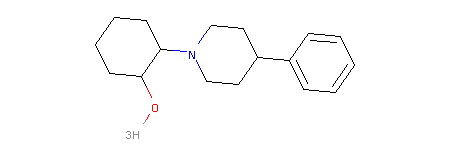

In [10]:
mol = Chem.MolFromSmiles('[3H]OC1CCCCC1N1CCC(c2ccccc2)CC1')
mol

In [9]:
df = pd.read_csv('./Data/ChEMBL_31/chembl_31_chemreps.txt', sep = '\t')
print(len(df.canonical_smiles.values))

pc = 20
with open("./Data/ChEMBL_31/chembl_31_chemreps_oh_35.txt", "w") as f:
    for id, s in zip (df.chembl_id.values, df.canonical_smiles.values):
        mol = Chem.MolFromSmiles(s)
        cohb = 0
        for b in mol.GetBonds():
            # H : 1, O : 8
            if b.GetBeginAtom().GetAtomicNum() == 1 and b.GetEndAtom().GetAtomicNum() == 8:
                cohb += 1
                # print('{}----->{}'.format(b.GetBeginAtom().GetAtomicNum(), b.GetEndAtom().GetAtomicNum()))
            elif b.GetBeginAtom().GetAtomicNum() == 8 and b.GetEndAtom().GetAtomicNum() == 1:
                cohb += 1
                # print('{}->{}'.format(b.GetBeginAtom().GetAtomicNum(), b.GetEndAtom().GetAtomicNum()))
        # print(cohb)
        if cohb > 0 and mol.GetNumAtoms() < 35:
            f.write('{}\t{}'.format(id, s))
            if pc >= 0:
                print('{}\t{}'.format(id, s))
                pc -= 1
print("done")

2304875
CHEMBL583001	[2H]O[C@H]1C[C@H](O[2H])CC(/C=C\C2=CCC[C@@]3(C)[C@@H]2CC[C@@H]3[C@H](C)CCCC(C)(C)O[2H])=C1C
CHEMBL578780	[2H]O[C@H]1C[C@H](O[2H])C/C(=C/C=C2\CCC[C@@]3(C)[C@H]2CC[C@@H]3[C@H](C)CCCC(C)(C)O[2H])C1=C


RDKit WARNING: [12:10:10] WARNING: not removing hydrogen atom without neighbors
[12:10:10] WARNING: not removing hydrogen atom without neighbors


CHEMBL4864547	[2H]O[C@H]1[C@@H](C)C[C@]2(OC(C)=O)C(=O)/C(C)=C/[C@@H]3[C@H](CC[C@]4(CO4)[C@H](OC(C)=O)[C@@H]12)C3(C)C
CHEMBL1163001	[3H]OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1F
CHEMBL1232306	[2H]O[2H]
CHEMBL1672899	[3H]Oc1ccc2nc(-c3ccc(NC)cc3)sc2c1
CHEMBL1788115	[3H]OC1CCCCC1N1CCC(c2ccccc2)CC1


RDKit WARNING: [12:13:47] WARNING: not removing hydrogen atom without neighbors
[12:13:47] WARNING: not removing hydrogen atom without neighbors


CHEMBL2092881	[3H]OC(=O)c1cc(CN2CCC(C#N)(c3ccccn3)CC2)c2ccccn2c1=O
CHEMBL2105800	[3H]O[3H]


RDKit WARNING: [12:15:00] WARNING: not removing hydrogen atom without neighbors
[12:15:00] WARNING: not removing hydrogen atom without neighbors
RDKit WARNING: [12:15:07] WARNING: not removing hydrogen atom without neighbors
[12:15:07] WARNING: not removing hydrogen atom without neighbors
RDKit WARNING: [12:15:12] WARNING: not removing hydrogen atom without neighbors
[12:15:12] WARNING: not removing hydrogen atom without neighbors


CHEMBL3249111	[3H]O[C@H]1C[C@@H](O)[C@H](/C=C/[C@@](C)(O)CCCCC)[C@H]1CC/C=C\CCC(=O)OC


RDKit WARNING: [12:17:03] WARNING: not removing hydrogen atom without neighbors
[12:17:03] WARNING: not removing hydrogen atom without neighbors
RDKit WARNING: [12:17:03] WARNING: not removing hydrogen atom without neighbors
RDKit WARNING: [12:17:03] WARNING: not removing hydrogen atom without neighbors
[12:17:03] WARNING: not removing hydrogen atom without neighbors
[12:17:03] WARNING: not removing hydrogen atom without neighbors
RDKit ERROR: [12:17:13] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 10 11 15 16 17 19 20 21
[12:17:13] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 10 11 15 16 17 19 20 21

RDKit ERROR: 


AttributeError: 'NoneType' object has no attribute 'GetBonds'